MSE 446 Project - Team 2

In [398]:
import pandas as pd


In [399]:
# Read song datasets
songs_popular = pd.read_csv('datasets/high_popularity_spotify_data.csv')
songs_notpopular = pd.read_csv('datasets/low_popularity_spotify_data.csv')

# artist popularity dataset
artist_popularity = pd.read_csv('datasets/spotify_data_artists.csv')

# combine low popularity and high popularity songs into one dataset
songs = pd.concat([songs_popular, songs_notpopular], ignore_index=True)



In [400]:

# Prepare artist dataset
artist_popularity = artist_popularity.rename(columns={
    'name': 'artist_name',
    'popularity': 'artist_popularity'
})

# Normalize artist names
artist_popularity['artist_name'] = artist_popularity['artist_name'].str.lower().str.strip()

# Create lookup dictionary
artist_top_track_popularity = dict(zip(
    artist_popularity['artist_name'],
    artist_popularity['artist_popularity']
))

# Function to find first matching artist
def get_artist_popularity(artist_string):
    if pd.isna(artist_string):
        return None
    
    artists = [a.strip().lower() for a in artist_string.split(',')]
    
    for artist in artists:
        if artist in artist_top_track_popularity:
            return artist_top_track_popularity[artist]
    
    return None  # no match found

# Apply function to get the artist popularity from the second dataset
songs['artist_popularity'] = songs['track_artist'].apply(get_artist_popularity)

In [401]:
# Build artist -> max track popularity dictionary
artist_top_track_popularity = {}

for _, row in songs.iterrows():
    artists = [a.strip() for a in row["track_artist"].split(",")]
    
    for artist in artists:
        current_pop = row["track_popularity"]
        
        if artist not in artist_top_track_popularity:
            artist_top_track_popularity[artist] = current_pop
        else:
            artist_top_track_popularity[artist] = max(artist_top_track_popularity[artist], current_pop)

print(artist_top_track_popularity)


# Step 2: Function to get the top popularity among the artists of a song
def get_top_popularity(artists):
    artist_list = [a.strip() for a in artists.split(",")]
    pops = [artist_top_track_popularity.get(a, 0) for a in artist_list]
    return max(pops)


# Step 3: Apply to dataframe
songs["artist_top_track_popularity"] = songs["track_artist"].apply(get_top_popularity)

{'Lady Gaga': 100, 'Bruno Mars': 100, 'Billie Eilish': 97, 'Gracie Abrams': 93, 'Sabrina Carpenter': 93, 'ROSÉ': 98, 'Chappell Roan': 94, 'Addison Rae': 88, 'Gigi Perez': 93, 'The Weeknd': 92, 'Playboi Carti': 92, 'Charli xcx': 85, 'Tate McRae': 79, 'Shaboozey': 86, 'LISA': 85, 'Morgan Wallen': 86, 'Adam Port': 86, 'Stryv': 86, 'Keinemusik': 86, 'Orso': 86, 'Malachiii': 86, 'Tyler': 90, 'The Creator': 90, 'GloRilla': 88, 'Sexyy Red': 88, 'Lil Wayne': 88, 'JENNIE': 89, 'Rauw Alejandro': 82, 'Bad Bunny': 84, 'Don Toliver': 85, 'Post Malone': 84, 'Hozier': 84, 'The Marías': 84, 'Oscar Maydon': 93, 'Fuerza Regida': 93, 'Myles Smith': 88, 'Ariana Grande': 86, 'Benson Boone': 89, 'Myke Towers': 84, 'benny blanco': 84, 'KATSEYE': 85, 'Teddy Swims': 89, 'Mark Ambor': 82, 'KAROL G': 93, 'Djo': 89, 'Taylor Swift': 84, 'Omar Courtz': 89, 'De La Rose': 89, 'Kendrick Lamar': 88, 'Jin': 85, 'Feid': 88, 'DFZM': 84, 'Ovy On The Drums': 84, 'J Balvin': 84, 'Maluma': 84, 'Ryan Castro': 84, 'Blessd': 84,

In [402]:
songs.head()

,energy,tempo,danceability,playlist_genre,loudness,liveness,valence,track_artist,time_signature,speechiness,track_popularity,track_href,uri,track_album_name,playlist_name,analysis_url,track_id,track_name,track_album_release_date,instrumentalness,track_album_id,mode,key,duration_ms,acousticness,id,playlist_subgenre,type,playlist_id,artist_popularity,artist_top_track_popularity
0,0.592,157.969,0.521,pop,-7.777,0.122,0.535,"Lady Gaga, Bruno Mars",3.0,0.0304,100,https://api.spotify.com/v1/tracks/2plbrEY59Iik...,spotify:track:2plbrEY59IikOBgBGLjaoe,Die With A Smile,Today's Top Hits,https://api.spotify.com/v1/audio-analysis/2plb...,2plbrEY59IikOBgBGLjaoe,Die With A Smile,2024-08-16,0.0000,10FLjwfpbxLmW8c25Xyc2N,0.0,6.0,251668.0,0.3080,2plbrEY59IikOBgBGLjaoe,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,88.0,100
1,0.507,104.978,0.747,pop,-10.171,0.117,0.438,Billie Eilish,4.0,0.0358,97,https://api.spotify.com/v1/tracks/6dOtVTDdiauQ...,spotify:track:6dOtVTDdiauQNBQEDOtlAB,HIT ME HARD AND SOFT,Today's Top Hits,https://api.spotify.com/v1/audio-analysis/6dOt...,6dOtVTDdiauQNBQEDOtlAB,BIRDS OF A FEATHER,2024-05-17,0.0608,7aJuG4TFXa2hmE4z1yxc3n,1.0,2.0,210373.0,0.2000,6dOtVTDdiauQNBQEDOtlAB,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,90.0,97
2,0.808,108.548,0.554,pop,-4.169,0.159,0.372,Gracie Abrams,4.0,0.0368,93,https://api.spotify.com/v1/tracks/7ne4VBA60CxG...,spotify:track:7ne4VBA60CxGM75vw0EYad,The Secret of Us (Deluxe),Today's Top Hits,https://api.spotify.com/v1/audio-analysis/7ne4...,7ne4VBA60CxGM75vw0EYad,That’s So True,2024-10-18,0.0000,0hBRqPYPXhr1RkTDG3n4Mk,1.0,1.0,166300.0,0.2140,7ne4VBA60CxGM75vw0EYad,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,82.0,93
3,0.910,112.966,0.670,pop,-4.070,0.304,0.786,Sabrina Carpenter,4.0,0.0634,81,https://api.spotify.com/v1/tracks/1d7Ptw3qYcfp...,spotify:track:1d7Ptw3qYcfpdLNL5REhtJ,Short n' Sweet,Today's Top Hits,https://api.spotify.com/v1/audio-analysis/1d7P...,1d7Ptw3qYcfpdLNL5REhtJ,Taste,2024-08-23,0.0000,4B4Elma4nNDUyl6D5PvQkj,0.0,0.0,157280.0,0.0939,1d7Ptw3qYcfpdLNL5REhtJ,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,91.0,93
4,0.783,149.027,0.777,pop,-4.477,0.355,0.939,"ROSÉ, Bruno Mars",4.0,0.2600,98,https://api.spotify.com/v1/tracks/5vNRhkKd0yEA...,spotify:track:5vNRhkKd0yEAg8suGBpjeY,APT.,Today's Top Hits,https://api.spotify.com/v1/audio-analysis/5vNR...,5vNRhkKd0yEAg8suGBpjeY,APT.,2024-10-18,0.0000,2IYQwwgxgOIn7t3iF6ufFD,0.0,0.0,169917.0,0.0283,5vNRhkKd0yEAg8suGBpjeY,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,78.0,100


In [403]:
songs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4831 entries, 0 to 4830
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   energy                       4830 non-null   float64
 1   tempo                        4830 non-null   float64
 2   danceability                 4830 non-null   float64
 3   playlist_genre               4831 non-null   object 
 4   loudness                     4830 non-null   float64
 5   liveness                     4830 non-null   float64
 6   valence                      4830 non-null   float64
 7   track_artist                 4831 non-null   object 
 8   time_signature               4830 non-null   float64
 9   speechiness                  4830 non-null   float64
 10  track_popularity             4831 non-null   int64  
 11  track_href                   4830 non-null   object 
 12  uri                          4830 non-null   object 
 13  track_album_name  

Max: 100.0
Min: 0.0


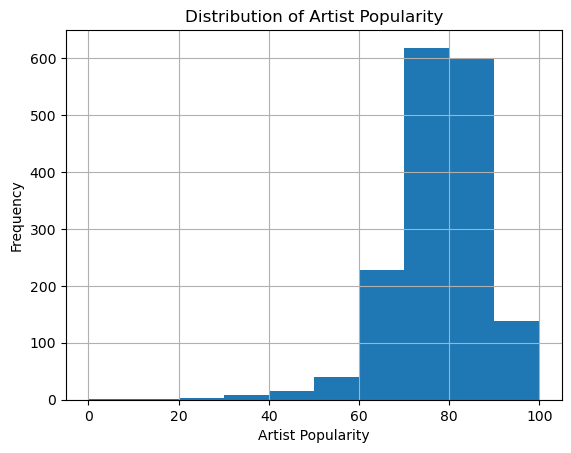

In [404]:
max_val = songs['artist_popularity'].max()
min_val = songs['artist_popularity'].min()

print("Max:", max_val)
print("Min:", min_val)

import matplotlib.pyplot as plt

songs['artist_popularity'].hist()
plt.xlabel('Artist Popularity')
plt.ylabel('Frequency')
plt.title('Distribution of Artist Popularity')
plt.show()

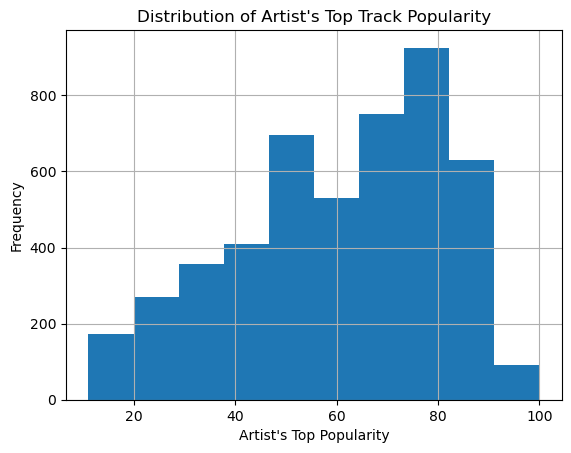

In [405]:
songs['artist_top_track_popularity'].hist()
plt.xlabel('Artist\'s Top Popularity')
plt.ylabel('Frequency')
plt.title('Distribution of Artist\'s Top Track Popularity')
plt.show()

In [406]:
songs['playlist_subgenre'].value_counts()

playlist_subgenre
modern         695
chill          420
classic        293
meditative     231
french         161
              ... 
noir             8
irish            6
heavy            5
post-rock        2
avant-garde      2
Name: count, Length: 84, dtype: int64

In [407]:
## Clean data

In [408]:
## Clean data
pd.set_option('display.max_columns', None)

# Count of duplicated rows
songs.duplicated().sum()

# Drop duplicated rows
songs.drop_duplicates()

# Duplicated tracks
songs['track_id'].duplicated()

# We can see that there are duplicate tracks with identical rows except the playlist subgenre. 
songs[songs['track_id'].duplicated(keep=False)].sort_values('track_id')
dupes = songs[songs['track_id'].duplicated(keep=False)]
dupes.groupby('track_id').nunique()

diff_cols = dupes.groupby('track_id').nunique()
diff_cols.loc[:, (diff_cols > 1).any()]

# Here we can see that the only columns that differ are playlist_genre, playlist_name, playlist_subgenre, playlist_id. We will combine them 
# to deal with the duplicated song ids. 
cols_to_combine = [
    'playlist_genre',
    'playlist_name',
    'playlist_subgenre',
    'playlist_id'
]

agg_dict = {col: lambda x: ', '.join(sorted(set(x))) for col in cols_to_combine}

# keep other columns
for col in songs.columns:
    if col not in cols_to_combine and col != 'track_id':
        agg_dict[col] = 'first'

songs = songs.groupby('track_id', as_index=False).agg(agg_dict)

songs

,track_id,playlist_genre,playlist_name,playlist_subgenre,playlist_id,energy,tempo,danceability,loudness,liveness,valence,track_artist,time_signature,speechiness,track_popularity,track_href,uri,track_album_name,analysis_url,track_name,track_album_release_date,instrumentalness,track_album_id,mode,key,duration_ms,acousticness,id,type,artist_popularity,artist_top_track_popularity
0,00Coyxt9mTec1acC52qtWa,korean,K-Drama OSTs,drama,37i9dQZF1DWUXxc8Mc6MmJ,0.735,111.961,0.643,-3.703,0.1010,0.502,TAEIL,4.0,0.0302,55,https://api.spotify.com/v1/tracks/00Coyxt9mTec...,spotify:track:00Coyxt9mTec1acC52qtWa,Twenty-Five Twenty-One OST Part 1,https://api.spotify.com/v1/audio-analysis/00Co...,Starlight,2022-02-13,0.000000,0w0hh5MzyFh2pyVZnn7Lo2,1.0,2.0,225817.0,0.078600,00Coyxt9mTec1acC52qtWa,audio_features,NaN,55
1,00DPAwQ3NkWs6PZKNxy7Pi,gospel,Modern Gospel,modern,4reKL9y3Zh2ccRcBKfAwuz,0.898,132.027,0.779,-4.589,0.1820,0.675,Olamilekan Akamo,4.0,0.0850,30,https://api.spotify.com/v1/tracks/00DPAwQ3NkWs...,spotify:track:00DPAwQ3NkWs6PZKNxy7Pi,Praise Combo,https://api.spotify.com/v1/audio-analysis/00DP...,Praise Combo,2023-09-24,0.142000,4LmzdtwhZqntC6vMAW8RgJ,1.0,8.0,1034000.0,0.022000,00DPAwQ3NkWs6PZKNxy7Pi,audio_features,NaN,30
2,00Gbi2ytn6ZmA1ObVcPT93,pop,Scandi Pop,scandi,59z06GgF6TTDbm5cr1RZUC,0.927,135.997,0.592,-5.278,0.6630,0.678,Smith & Thell,4.0,0.0439,31,https://api.spotify.com/v1/tracks/00Gbi2ytn6Zm...,spotify:track:00Gbi2ytn6ZmA1ObVcPT93,Pixie's Parasol,https://api.spotify.com/v1/audio-analysis/00Gb...,Pixie's Parasol,2021-10-22,0.000000,4giKFINYxPLvnV0fBsv4Vw,1.0,7.0,182947.0,0.013800,00Gbi2ytn6ZmA1ObVcPT93,audio_features,NaN,36
3,00JOgmWv6RmkgwPxdYScnf,arabic,Middle Eastern Beats,modern,0Hyn0Bj7eWczyQdhkNAYFR,0.472,140.976,0.415,-11.089,0.2130,0.067,Greg Edmonson,4.0,0.0373,27,https://api.spotify.com/v1/tracks/00JOgmWv6Rmk...,spotify:track:00JOgmWv6RmkgwPxdYScnf,Uncharted 3: Drake's Deception (Original Sound...,https://api.spotify.com/v1/audio-analysis/00JO...,Atlantis of the Sands,2011,0.750000,5LrG1kmYsNmMvKh9ofcvrc,1.0,2.0,153347.0,0.205000,00JOgmWv6RmkgwPxdYScnf,audio_features,37.0,27
4,00Mb3DuaIH1kjrwOku9CGU,punk,Pop Punk Powerhouses,pop punk,72GgLgQ63eUHG3CyCv42Ju,0.900,149.937,0.487,-4.417,0.3580,0.484,Avril Lavigne,4.0,0.0482,77,https://api.spotify.com/v1/tracks/00Mb3DuaIH1k...,spotify:track:00Mb3DuaIH1kjrwOku9CGU,Let Go,https://api.spotify.com/v1/audio-analysis/00Mb...,Sk8er Boi,2002-06-04,0.000000,3zXjR3y2dUWklKmmp6lEhy,1.0,0.0,204000.0,0.000068,00Mb3DuaIH1kjrwOku9CGU,audio_features,76.0,81
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4490,7z58tb8L6MUn6ybmTQXU1g,brazilian,Samba Essentials,samba,1BpZnLrg2Kdects466K3w7,0.789,91.086,0.610,-7.859,0.1060,0.757,Almir Guineto,4.0,0.0842,23,https://api.spotify.com/v1/tracks/7z58tb8L6MUn...,spotify:track:7z58tb8L6MUn6ybmTQXU1g,Almir Guineto,https://api.spotify.com/v1/audio-analysis/7z58...,Pedi Ao Céu,1999-01-01,0.000003,2lKQuc7knxMoMicyTznmkZ,0.0,5.0,215160.0,0.457000,7z58tb8L6MUn6ybmTQXU1g,audio_features,NaN,61
4491,7zIMsHKE8eyUu7mPt2Md8I,brazilian,Samba Essentials,samba,1BpZnLrg2Kdects466K3w7,0.688,99.438,0.454,-8.636,0.4490,0.763,Grupo Fundo De Quintal,4.0,0.0621,22,https://api.spotify.com/v1/tracks/7zIMsHKE8eyU...,spotify:track:7zIMsHKE8eyUu7mPt2Md8I,É Aí Que Quebra a Rocha,https://api.spotify.com/v1/audio-analysis/7zIM...,A Amizade,1991-01-01,0.000000,7lL3hyWKXlsGmVPbB6tIWR,1.0,7.0,196000.0,0.696000,7zIMsHKE8eyUu7mPt2Md8I,audio_features,NaN,48
4492,7zbLSEX8OfsuK3j7A1MRSw,brazilian,Forró Fiesta,forró,1LJ43C0twQIzhP54v7Gt54,0.766,166.989,0.649,-7.065,0.0707,0.885,Elba Ramalho,4.0,0.0533,32,https://api.spotify.com/v1/tracks/7zbLSEX8Ofsu...,spotify:track:7zbLSEX8OfsuK3j7A1MRSw,Elba Canta Luiz,https://api.spotify.com/v1/audio-analysis/7zbL...,Numa Sala de Reboco,2002-03-15,0.000000,0hea6Rtz0qgNQr3uEn13Hm,1.0,7.0,196640.0,0.267000,7zbLSEX8OfsuK3j7A1MRSw,audio_features,NaN,38
4493,7zjkSx1EUums3s1Y

In [409]:
## Deal with missing values
songs.isna().sum().sort_values(ascending=False)

# We are aware of the missing artist popularity. We will replace these with 0s.
songs.isna().sum().sort_values(ascending=False)

#The others each have only one row so we will drop it. 
songs = songs.dropna()

In [410]:
# removing unneeded columns
songs = songs.drop(columns=['track_href', 'playlist_id', "track_album_release_date", "track_album_id"], errors='ignore')
songs = songs.drop(columns=['uri', "duration_ms", 'track_album_name'])
songs = songs.drop(columns=['analysis_url', 'playlist_name', 'type'])


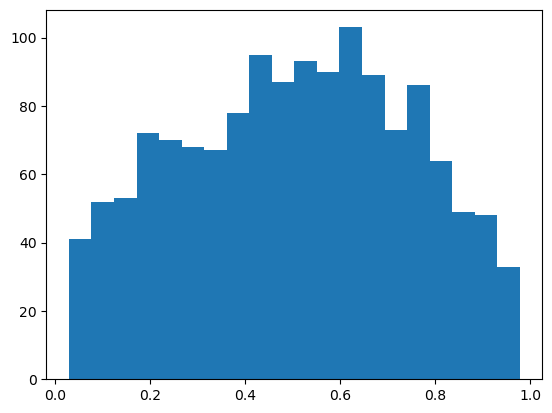

In [411]:
# Valence 
# We can see no outliers and is already scaled between 0 and 1. No prep needed. 
plt.hist(songs['valence'], bins=20)
plt.show()

In [412]:
# Time signature
# 4 unique values - treat as categorical, one hot encode
songs['time_signature'].nunique()

songs['time_signature'] = songs['time_signature'].astype('category')

from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False)
encoded = encoder.fit_transform(songs[['time_signature']])
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(['time_signature']))
songs = pd.concat([songs, encoded_df], axis=1)

songs = songs.drop(columns=['time_signature'])

In [413]:
# Key
# 12 unique values - treat as categorical, one hot encode
songs['key'].nunique()

songs['key'] = songs['key'].astype('category')

from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False)
encoded = encoder.fit_transform(songs[['key']])
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(['key']))
songs = pd.concat([songs, encoded_df], axis=1)

songs = songs.drop(columns=['key', 'key_nan'])

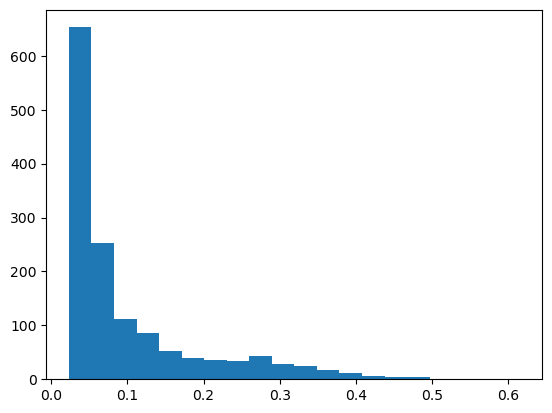

In [414]:
# speechiness
plt.hist(songs['speechiness'], bins=20)
plt.show()

# Can see that most data is close to 0, with long tail and max around 0.6. 
# Use MinMax Scaler to put on 0-1 scale
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
songs['speechiness'] = scaler.fit_transform(songs[['speechiness']])

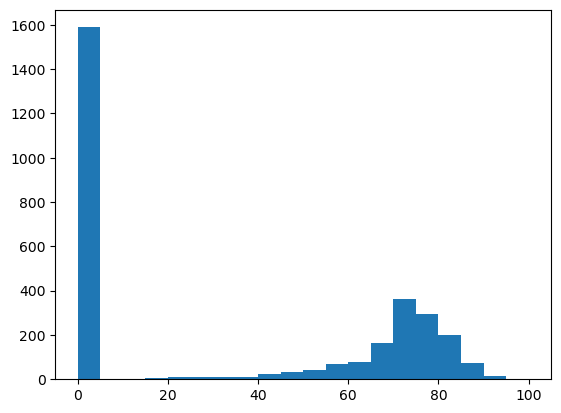

In [415]:
# track_popularity
songs['track_popularity'].isna().sum()

# fill with 0s to represnt missing/unknown. The model will be blind to popularity during training so missing values are not important. 
songs['track_popularity'] = songs['track_popularity'].fillna(0)
songs['track_popularity'].isna().sum()

plt.hist(songs['track_popularity'], bins=20)
plt.show()

# Use MinMaxScaler to scale 
scaler = MinMaxScaler()
songs['track_popularity'] = scaler.fit_transform(songs[['track_popularity']])

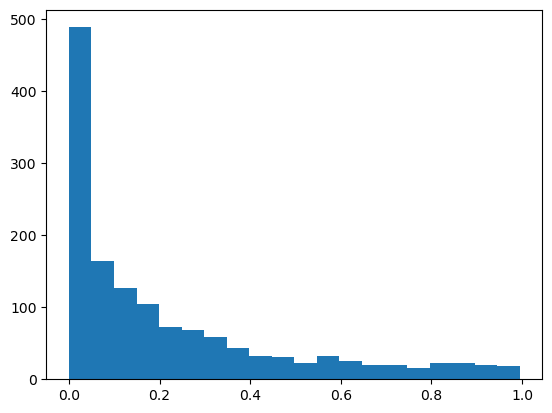

In [416]:
# Make popularity columns on a scale of 0-1
songs['artist_popularity'] = songs['artist_popularity'] / 100
songs['artist_top_track_popularity'] = songs['artist_top_track_popularity'] / 100

# Encode categorical columns to binary values (adds a column per subgenre)
subgenre_dummies = songs['playlist_subgenre'].str.get_dummies(sep=', ')

#Add prefix to keep column names clear
subgenre_dummies = subgenre_dummies.add_prefix('playlist_subgenre_')

#Join back to dataset
songs = pd.concat([songs, subgenre_dummies], axis=1)

#Drop original column
songs = songs.drop(columns=['playlist_subgenre'])


plt.hist(songs['acousticness'], bins=20)
plt.show()

In [417]:
from sklearn.preprocessing import MinMaxScaler

cols_to_scale = ['energy', 'tempo', 'danceability', 'loudness', 'liveness']

scaler = MinMaxScaler()
songs[cols_to_scale] = scaler.fit_transform(songs[cols_to_scale])

# songs = pd.get_dummies(songs, columns=['playlist_genre'], drop_first=True)

# Encode categorical columns to binary values (adds a column per subgenre)
subgenre_dummies = songs['playlist_genre'].str.get_dummies(sep=', ')

#Add prefix to keep column names clear
subgenre_dummies = subgenre_dummies.add_prefix('playlist_genre_')

#Join back to dataset
songs = pd.concat([songs, subgenre_dummies], axis=1)

#Drop original column
songs = songs.drop(columns=['playlist_genre'])


In [418]:
songs.head()

,track_id,energy,tempo,danceability,loudness,liveness,valence,track_artist,speechiness,track_popularity,track_name,instrumentalness,mode,acousticness,id,artist_popularity,artist_top_track_popularity,time_signature_1.0,time_signature_3.0,time_signature_4.0,time_signature_5.0,key_0.0,key_1.0,key_2.0,key_3.0,key_4.0,key_5.0,key_6.0,key_7.0,key_8.0,key_9.0,key_10.0,key_11.0,playlist_subgenre_80s,playlist_subgenre_90s,playlist_subgenre_academic,playlist_subgenre_african,playlist_subgenre_afro house,playlist_subgenre_afro-latin,playlist_subgenre_alternative,playlist_subgenre_american,playlist_subgenre_anime,playlist_subgenre_australian,playlist_subgenre_bedroom,playlist_subgenre_chill,playlist_subgenre_choral,playlist_subgenre_cinematic,playlist_subgenre_classic,playlist_subgenre_death,playlist_subgenre_deep house,playlist_subgenre_desi,playlist_subgenre_drama,playlist_subgenre_drill,playlist_subgenre_essential,playlist_subgenre_feel-good,playlist_subgenre_forró,playlist_subgenre_french,playlist_subgenre_future bass,playlist_subgenre_gangster,playlist_subgenre_global,playlist_subgenre_hardstyle,playlist_subgenre_heavy,playlist_subgenre_hip-hop,playlist_subgenre_indie,playlist_subgenre_irish,playlist_subgenre_italo,playlist_subgenre_mainstream,playlist_subgenre_meditative,playlist_subgenre_melodic,playlist_subgenre_modern,playlist_subgenre_neo-classical,playlist_subgenre_nigerian,playlist_subgenre_noir,playlist_subgenre_pop punk,playlist_subgenre_reggaeton,playlist_subgenre_scandi,playlist_subgenre_soft,playlist_subgenre_soundtracks,playlist_subgenre_southern,playlist_subgenre_spanish,playlist_subgenre_techno,playlist_subgenre_throat singing,playlist_subgenre_throwback,playlist_subgenre_trap,playlist_subgenre_tropical,playlist_subgenre_vaporwave,playlist_subgenre_workout,playlist_genre_afrobeats,playlist_genre_ambient,playlist_genre_arabic,playlist_genre_blues,playlist_genre_brazilian,playlist_genre_classical,playlist_genre_country,playlist_genre_disco,playlist_genre_electronic,playlist_genre_folk,playlist_genre_gaming,playlist_genre_gospel,playlist_genre_hip-hop,playlist_genre_indian,playlist_genre_indie,playlist_genre_j-pop,playlist_genre_jazz,playlist_genre_k-pop,playlist_genre_korean,playlist_genre_latin,playlist_genre_lofi,playlist_genre_metal,playlist_genre_pop,playlist_genre_punk,playlist_genre_r&b,playlist_genre_rock,playlist_genre_soul,playlist_genre_world
3,00JOgmWv6RmkgwPxdYScnf,0.472683,0.580035,0.383667,0.724290,0.206897,0.067,Greg Edmonson,0.023991,0.27,Atlantis of the Sands,0.75,1.0,0.205000,00JOgmWv6RmkgwPxdYScnf,0.37,0.27,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,00Mb3DuaIH1kjrwOku9CGU,0.903392,0.637691,0.462910,0.886464,0.363147,0.484,Avril Lavigne,0.042406,0.77,Sk8er Boi,0.00,1.0,0.000068,00Mb3DuaIH1kjrwOku9CGU,0.76,0.81,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
6,00n83h3zn2IrySO4Q4aTrG,0.589417,0.412444,0.710544,0.864223,0.203664,0.471,Lil Tecca,0.052712,0.70,Down With Me,0.00,0.0,0.112000,00n83h3zn2IrySO4Q4aTrG,0.79,0.84,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
7,01K4zKU104LyJ8gMb7227B,0.377082,0.328999,0.593881,0.764007,0.143319,0.446,"Taylor Swift, Phoebe Bridgers",0.007434,0.71,Nothing New (feat. Phoebe Bridgers) (Taylor’s ...,0.00,1.0,0.817000,01K4zKU104LyJ8gMb7227B,1.00,0.84,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,